# CE 738 — Assignment 1
### Linear Models for Transportation Data

**Name:** Anh Le &nbsp;&nbsp;|&nbsp;&nbsp; **Date:** September 26, 2026

Two linear models on the same traffic dataset:

- **Part 1 — Classification:** predict `traffic_class` (0/1/2) using PyTorch built-ins.
- **Part 2 — Regression:** predict `travel_time_min` written from scratch (manual batching, loss, and SGD update).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Fixed seed: with only 30 samples, results change between runs without one.
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

## 1. Load the data

In [2]:
df = pd.read_csv("data/transportation.csv")   # relative path, so the notebook stays runnable
df.head()

,record_id,traffic_volume_vph,occupancy_pct,average_speed_mph,rainfall_mm,travel_time_min,traffic_class
0,1,320,7,64,0,7.6,0
1,2,410,9,62,0,8.0,0
2,3,500,11,60,1,8.5,0
3,4,590,13,58,0,9.0,0
4,5,680,15,56,2,9.7,0


In [3]:
print("Shape:", df.shape)
print("\nClass balance:")
print(df["traffic_class"].value_counts().sort_index().to_string())

Shape: (30, 7)

Class balance:
traffic_class
0    10
1    10
2    10


Only **30 rows**, with the 3 classes balanced. That is too few to hold out a test set,
so every score below is a **training** metric — it measures fit, not generalization.

## 2. Features and targets

Four features are used for both parts. `record_id` is excluded because it is just a row counter.

In [4]:
feature_cols = ["traffic_volume_vph", "occupancy_pct", "average_speed_mph", "rainfall_mm"]

X_raw = df[feature_cols].values.astype(np.float64)
y_cls_raw = df["traffic_class"].values      # Part 1 target (labels)
y_reg_raw = df["travel_time_min"].values    # Part 2 target (continuous)

## 3. Standardization

The features have very different scales (volume in the thousands, rainfall in single digits).
Gradient descent uses one learning rate for all weights, so the features are rescaled to
zero mean and unit variance to make that single rate work for all of them.

In [5]:
mu, sigma = X_raw.mean(axis=0), X_raw.std(axis=0)
X_norm = (X_raw - mu) / sigma

pd.DataFrame({"mean": mu.round(2), "std": sigma.round(2)}, index=feature_cols)

,mean,std
traffic_volume_vph,1072.67,439.73
occupancy_pct,32.03,18.23
average_speed_mph,41.73,14.32
rainfall_mm,2.20,2.21


In [6]:
# These features are highly correlated with each other (speed vs. volume ~ -1.0),
# which slows convergence and makes individual weights hard to interpret later.
df[feature_cols].corr().round(3)

,traffic_volume_vph,occupancy_pct,average_speed_mph,rainfall_mm
traffic_volume_vph,1.000,0.987,-0.998,0.570
occupancy_pct,0.987,1.000,-0.992,0.606
average_speed_mph,-0.998,-0.992,1.000,-0.587
rainfall_mm,0.570,0.606,-0.587,1.000


---
# Part 1 — Classification (PyTorch built-ins)

In [7]:
# Features must be float32; class labels must be long (int64) for CrossEntropyLoss.
X_tensor = torch.tensor(X_norm, dtype=torch.float32)
y_cls = torch.tensor(y_cls_raw, dtype=torch.long)

# batch_size=8 gives 4 batches per epoch. (A batch size of 32 would exceed the
# 30-row dataset and collapse to a single full-batch update.)
dataset = TensorDataset(X_tensor, y_cls)
dataloader = DataLoader(dataset, batch_size=8, shuffle=True)

print("Batches per epoch:", len(dataloader))

Batches per epoch: 4


In [8]:
d_in = X_tensor.shape[1]
num_classes = len(torch.unique(y_cls))

model_cls = nn.Linear(d_in, num_classes)   # outputs raw logits, no softmax
criterion = nn.CrossEntropyLoss()          # applies softmax internally
optimizer = optim.SGD(model_cls.parameters(), lr=0.05)

### Training

200 epochs.

In [9]:
EPOCHS_CLS = 200
loss_hist, acc_hist = [], []

for epoch in range(EPOCHS_CLS):
    epoch_loss = 0.0
    for X_batch, y_batch in dataloader:
        optimizer.zero_grad()                 # gradients accumulate, so clear them first
        loss = criterion(model_cls(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * X_batch.size(0)

    with torch.no_grad():
        acc = (model_cls(X_tensor).argmax(dim=1) == y_cls).float().mean().item()

    loss_hist.append(epoch_loss / len(dataset))
    acc_hist.append(acc)

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1:4d} | loss = {loss_hist[-1]:.4f} | accuracy = {acc:.4f}")

Epoch   20 | loss = 0.4938 | accuracy = 0.8333
Epoch   40 | loss = 0.3760 | accuracy = 0.9333
Epoch   60 | loss = 0.3135 | accuracy = 0.9667
Epoch   80 | loss = 0.2735 | accuracy = 0.9667
Epoch  100 | loss = 0.2447 | accuracy = 0.9667
Epoch  120 | loss = 0.2233 | accuracy = 0.9667
Epoch  140 | loss = 0.2068 | accuracy = 0.9667
Epoch  160 | loss = 0.1935 | accuracy = 0.9667
Epoch  180 | loss = 0.1828 | accuracy = 0.9667
Epoch  200 | loss = 0.1732 | accuracy = 0.9667


In [10]:
with torch.no_grad():
    y_pred_cls = model_cls(X_tensor).argmax(dim=1)   # largest logit = predicted class

accuracy = (y_pred_cls == y_cls).float().mean().item()
print(f"Training accuracy: {accuracy:.4f}  ({int((y_pred_cls == y_cls).sum())}/{len(y_cls)})")

# Confusion matrix (rows = true, columns = predicted)
cm = torch.zeros(num_classes, num_classes, dtype=torch.long)
for t, p in zip(y_cls, y_pred_cls):
    cm[t, p] += 1

print()
print(pd.DataFrame(cm.numpy(),
                   index=[f"true {k}" for k in range(num_classes)],
                   columns=[f"pred {k}" for k in range(num_classes)]).to_string())

Training accuracy: 0.9667  (29/30)

        pred 0  pred 1  pred 2
true 0      10       0       0
true 1       1       9       0
true 2       0       0      10


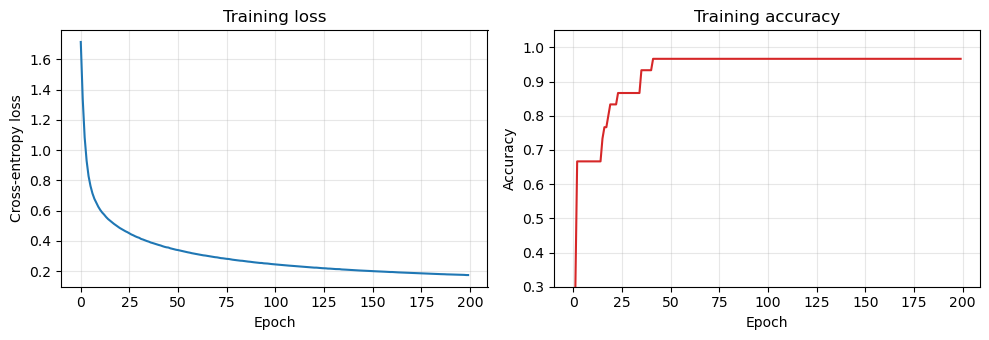

In [11]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))

ax[0].plot(loss_hist)
ax[0].set(xlabel="Epoch", ylabel="Cross-entropy loss", title="Training loss")

ax[1].plot(acc_hist, color="tab:red")
ax[1].set(xlabel="Epoch", ylabel="Accuracy", title="Training accuracy", ylim=(0.3, 1.05))

for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Result:** 96.7% training accuracy (29/30) — one moderate-traffic sample is predicted as
free-flow. The loss is still falling at epoch 200, so the model is not fully converged;
training longer reaches 100%, which means the classes are linearly separable and a single
linear layer is enough.

---
# Part 2 — Regression (from scratch)

Same data, continuous target, but `nn.Linear`, `MSELoss`, and `optim.SGD` are replaced
by hand-written code.

In [12]:
# Named y_reg, not y_tensor, so it cannot overwrite the Part 1 labels.
# Shaped (30, 1) to match the output of X @ w + b and avoid broadcasting errors.
y_reg = torch.tensor(y_reg_raw, dtype=torch.float32).reshape(-1, 1)
features = X_tensor      # reuse the standardized features from Part 1

print("features:", tuple(features.shape), " y_reg:", tuple(y_reg.shape))

features: (30, 4)  y_reg: (30, 1)


### Mini-batch iterator

Replaces `DataLoader`. Reshuffles each epoch because the rows are sorted by congestion level.
The shuffle is reproducible from the seed set at the top of the notebook.

In [13]:
def data_iter(batch_size, features, labels):
    """Yield shuffled (features, labels) mini-batches, one at a time."""
    num_examples = len(features)
    indices = torch.randperm(num_examples)   # reproducible via the seed set at the top
    for i in range(0, num_examples, batch_size):
        batch_indices = indices[i : min(i + batch_size, num_examples)]
        yield features[batch_indices], labels[batch_indices]


# 30 rows at batch size 8 -> the last batch holds only 6.
print("Batch sizes:", [xb.shape[0] for xb, _ in data_iter(8, features, y_reg)])

Batch sizes: [8, 8, 8, 6]


### Model and loss

`requires_grad=True` lets autograd track `w` and `b` so `.backward()` can fill their gradients.

The training loss is squared error multiplied by 1/2. The 1/2 exists only to make the
derivative clean — $\frac{d}{d\hat{y}}\,\frac{1}{2}(\hat{y}-y)^2 = \hat{y}-y$, with no
leftover factor of 2 in the gradient. It is a convenience for the hand-written update,
**not** a metric: every number reported below is multiplied by 2 to give the true MSE.

In [14]:
d = features.shape[1]
w = torch.normal(0, 0.01, size=(d, 1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)


def net(X):
    """Linear model: y_hat = Xw + b"""
    return X @ w + b


def squared_loss(y_hat, y):
    """Half squared error, used for training only (see note above)."""
    return (y_hat - y.reshape(y_hat.shape)) ** 2 / 2

### Training

This is what `optimizer.step()` normally does. The update runs inside `torch.no_grad()` so it
is not recorded by autograd, and gradients are cleared by hand since there is no optimizer object.

The features are highly correlated, which makes convergence slow — 200 epochs gets close
but does not fully reach the least-squares solution.

In [15]:
lr = 0.03
batch_size = 8
EPOCHS_REG = 200
mse_hist = []

for epoch in range(EPOCHS_REG):
    for X_batch, y_batch in data_iter(batch_size, features, y_reg):
        l = squared_loss(net(X_batch), y_batch).sum()
        l.backward()

        with torch.no_grad():
            for p in (w, b):
                # Divide by the ACTUAL batch size (6 on the last batch, not 8)
                # to turn the summed gradient into a mean gradient.
                p -= lr * p.grad / X_batch.shape[0]
                p.grad.zero_()

    with torch.no_grad():
        # x2 converts the half squared error used for training into the true MSE.
        mse_hist.append(2 * squared_loss(net(features), y_reg).mean().item())

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1:4d} | MSE = {mse_hist[-1]:7.4f} | "
              f"RMSE = {np.sqrt(mse_hist[-1]):.4f} min")

Epoch   20 | MSE =  5.2887 | RMSE = 2.2997 min
Epoch   40 | MSE =  2.9541 | RMSE = 1.7188 min
Epoch   60 | MSE =  2.7648 | RMSE = 1.6628 min
Epoch   80 | MSE =  2.6117 | RMSE = 1.6161 min
Epoch  100 | MSE =  2.4637 | RMSE = 1.5696 min
Epoch  120 | MSE =  2.3264 | RMSE = 1.5252 min
Epoch  140 | MSE =  2.2002 | RMSE = 1.4833 min
Epoch  160 | MSE =  2.0770 | RMSE = 1.4412 min
Epoch  180 | MSE =  1.9633 | RMSE = 1.4012 min
Epoch  200 | MSE =  1.8578 | RMSE = 1.3630 min


### Results

Three standard metrics are reported, each for a different reason:

- **MSE** — the quantity the training actually minimizes, so it is the fair number to
  compare against the least-squares optimum.
- **RMSE** — the square root of MSE, so it is in **minutes**, the same units as the target.
  This is the one to quote for "how far off is a typical prediction".
- **R²** — unit-free, the fraction of the variance in travel time the model explains.

The closed-form least-squares solution is also computed, as a reference for the best any
linear model can do on this data.

In [16]:
with torch.no_grad():
    y_hat = net(features)
    mse = 2 * squared_loss(y_hat, y_reg).mean().item()   # x2 undoes the 1/2 in the loss

rmse = np.sqrt(mse)
r2 = 1 - ((y_reg - y_hat) ** 2).sum().item() / ((y_reg - y_reg.mean()) ** 2).sum().item()

# Reference: exact least-squares optimum (the best any linear model can do here)
A = np.c_[X_norm, np.ones(len(X_norm))]
beta_ols, *_ = np.linalg.lstsq(A, y_reg_raw, rcond=None)
ols_mse = ((A @ beta_ols - y_reg_raw) ** 2).mean()

print(f"MSE  : {mse:.4f} min^2   (least-squares optimum = {ols_mse:.4f})")
print(f"RMSE : {rmse:.4f} min")
print(f"R^2  : {r2:.4f}")

MSE  : 1.8578 min^2   (least-squares optimum = 0.1983)
RMSE : 1.3630 min
R^2  : 0.9747


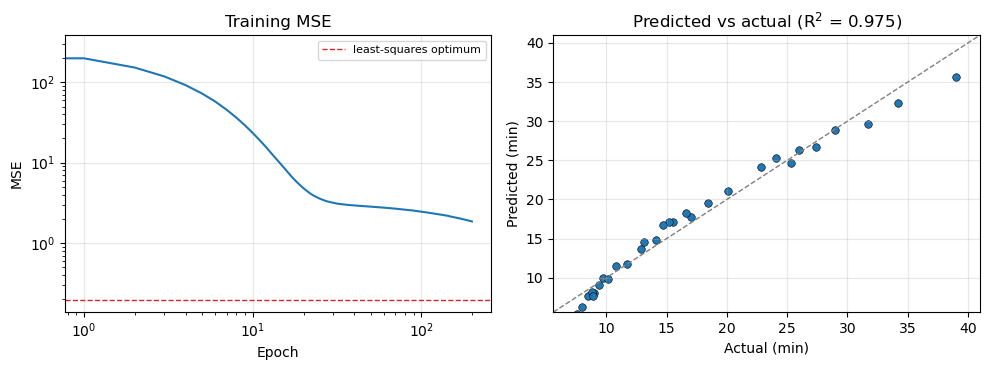

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.8))

ax[0].plot(mse_hist)
ax[0].axhline(ols_mse, ls="--", c="tab:red", lw=1, label="least-squares optimum")
ax[0].set(xscale="log", yscale="log", xlabel="Epoch", ylabel="MSE", title="Training MSE")
ax[0].legend(fontsize=8)

yt, yp = y_reg.numpy().ravel(), y_hat.numpy().ravel()
lims = [yt.min() - 2, yt.max() + 2]
ax[1].plot(lims, lims, ls="--", c="gray", lw=1)
ax[1].scatter(yt, yp, s=30, edgecolor="k", linewidth=0.4)
ax[1].set(xlim=lims, ylim=lims, xlabel="Actual (min)", ylabel="Predicted (min)",
          title=f"Predicted vs actual (R$^2$ = {r2:.3f})")

for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Weights act on standardized features: change in travel time per 1 std of each feature.
pd.DataFrame({
    "SGD": np.r_[w.detach().numpy().ravel(), b.detach().numpy()].round(2),
    "least-squares": beta_ols.round(2),
}, index=feature_cols + ["bias"])

,SGD,least-squares
traffic_volume_vph,0.44,-3.12
occupancy_pct,5.89,15.56
average_speed_mph,-1.35,4.47
rainfall_mm,1.09,0.69
bias,17.32,17.32


**Result:** RMSE ≈ 1.36 min and R² ≈ 0.975 — typical predictions are within about a minute
and a half. The MSE (1.86) is still well above the least-squares optimum (0.20), so SGD has
not fully converged at 200 epochs.

This shows in the coefficient table too: the SGD weights are still far short of the
least-squares values (e.g. `occupancy_pct` 5.89 vs 15.56). `occupancy_pct` is nonetheless
already the dominant weight, which makes sense since it measures how densely packed the
road is. The weights are still moving, so they should not yet be read as physical effects.

---
## Summary

| | Part 1 | Part 2 |
|---|---|---|
| Target | `traffic_class` | `travel_time_min` |
| Method | PyTorch built-ins | from scratch |
| Result | 96.7% accuracy | RMSE ≈ 1.36 min, R² ≈ 0.975 |

Both linear models fit this dataset well. The main points from the assignment:

1. The from-scratch version reproduces exactly what the built-ins do — `optimizer.step()`
   is just `p -= lr * p.grad`.
2. Standardization is what lets one learning rate work across features of very different scales.
3. At 200 epochs both models still have a falling loss, so neither is fully converged —
   the limit here is the epoch budget, not the model.
4. All scores are training scores. With 30 samples there is no held-out data, so these
   measure fit rather than generalization.